<a href="https://colab.research.google.com/github/ceuratfmg2mai/fakereviews/blob/main/02.%20categorizar_reviews_human.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción

Tras la selección de reseñas del conjunto de datos de Yelp, detallada en el [note book 1](https://github.com/ceuratfmg2mai/fakereviews/blob/main/01.%20procesamiento_datos_yelp.ipynb) abordamos el desafío de su categorización. Para ello, el subconjunto de reseñas seleccionado se distribuyó equitativamente entre el equipo de trabajo. La categorización se fundamentó en un análisis empírico de usuarios y comportamientos anómalos, con énfasis en características que la literatura señala como potencialmente indicativas de actividad sospechosa:

* Usuarios con puntuaciones extremadamente bajas y relativamente pocos votos “cool” tienden a ser considerados como generadores de reseñas falsas.
* Usuarios con puntuaciones intermedias (entre 3.09 y 4.96) y un número moderado o bajo de reseñas suelen mostrar patrones auténticos.
* Usuarios con puntuaciones excesivamente altas (> 4.96) y baja actividad o escasa interacción (pocos votos "funny", baja antigüedad, pocas reseñas) pueden ser sospechosos de actividad automatizada o fabricada



**Nota**: Los dataset están localizados en: *https://drive.google.com/drive/folders/1gNQNt4MHCHT-FiHXVTqz4vfKhgX7jfjY?usp=sharing*

# Librerías

In [40]:
import polars as pl
import pandas as pd
import pyarrow
import sys

import matplotlib.pyplot as plt
plt.style.use('Solarize_Light2')

import seaborn as sns
import time
start_time_global = time.time()
import json
import os
from google.colab import drive
from IPython.display import clear_output


color = '\033[1m\033[38;5;208m'
print(f"{color}Versión pandas: {pd.__version__}")
print(f"{color}Versión polars: {pl.__version__}")
print(f"{color}Versión pyarrow: {pyarrow.__version__}")

Versión pandas: 2.2.2
Versión polars: 1.21.0
Versión pyarrow: 18.1.0


# Inicialización y configuración de variables genéricas

# 1 - Inicialización de las variables de entorno

In [41]:
drive.mount('/content/drive', force_remount=True)
explicit_work_path = '/content/drive/MyDrive/Colab Notebooks/tfm_grupo_2/'
print(os.listdir(explicit_work_path))

Mounted at /content/drive
['yelp_academic_dataset_review_selected_0_255.jsonl', 'data_yelp', 'yelp_academic_dataset_review_selected.jsonl', 'yelp_academic_dataset_review_selected.arrow', 'yelp_academic_dataset_review_selected.csv', 'yelp_academic_dataset_review_selected_prompt.arrow', 'yelp_academic_dataset_review_selected_prompt.jsonl', 'yelp_academic_dataset_review_final_selected_1900.jsonl', 'yelp_academic_dataset_review_golden_evaluador_1.jsonl', 'yelp_academic_dataset_review_golden_evaluador_2.json', 'reviews_22052025.arrow', 'reviews_22052025.jsonl', 'reviews_22052025.csv', 'reviews_22052025_100.jsonl', 'reviews_22052025_1950.jsonl', 'reviews_22052025_100.csv', 'reviews_22052025_1950.arrow', 'reviews_22052025_1950.csv', 'reviews_22052025_100.arrow']


# 2 - Lectura del fichero de las reseñas categorizadas por humanos.

En este apartado, leeremos con Polars el conjunto completo de los datos seleccionados.

In [42]:
# Lectura del fichero de las reseñas seleccionadas de yelp
review_selected_file_path = f'{explicit_work_path}reviews_22052025.jsonl'
df_data_reviews_selected_pl = pl.read_ndjson(review_selected_file_path)
print(f"\nTotal de reseñas a procesar: {df_data_reviews_selected_pl.shape[0]}")


Total de reseñas a procesar: 1950


## Visualización de la distribución
A continuación, detallamos visualmente el resultado realizado de la categorización realizada por los humanos.

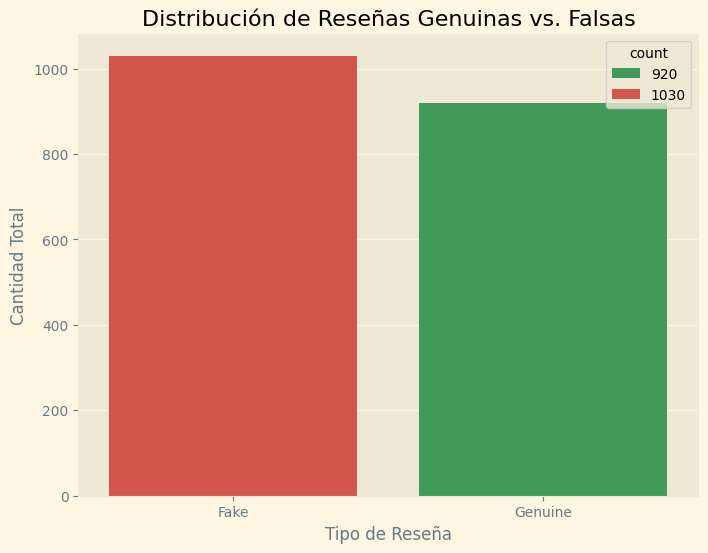

In [43]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_data_reviews_selected_pl['Cluster'].value_counts().to_pandas()
df_counts['Cluster'] = df_counts['Cluster'].replace({0: 'Fake', 1: 'Genuine'})
# Crear el gráfico de barras con Seaborn y Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Cluster', y='count', data=df_counts, palette=['#34A853', '#EA4335'], hue='count') # Genuine (verde), Fake (rojo)

# Añadir títulos y etiquetas
plt.title('Distribución de Reseñas Genuinas vs. Falsas', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()


# 3 - Separación del conjunto de datos

Para la creación de los conjuntos de entrenamiento (Training Set), validación (Validation Set) y prueba (Test Set) necesarios para nuestros modelos, procederemos de la siguiente manera con las reseñas disponibles:

1. Inicialmente, se reservarán 100 reseñas que conformarán el conjunto de prueba (Test Set).
2. Las reseñas restantes, tras excluir las destinadas al conjunto de prueba, constituirán el conjunto combinado de datos para entrenamiento y validación. Este conjunto se dividirá posteriormente para crear los conjuntos de entrenamiento y validación específicos.

In [44]:
# Separamos 100 registros para el conjunto de prueba (Test Set)
df_100 = df_data_reviews_selected_pl.sample(n=100, seed=42)
print("Número de registros seleccionados para Test:", df_100.shape[0])
#  Separamos (Training Set) y validación (Validation Set)
df_restante = df_data_reviews_selected_pl.join(
    df_100.select("review_id"),
    on="review_id",
    how="anti"
)
print("Número de registros restantes (Train/Validation):", df_restante.shape[0])
print("Total de registros (Test + Train/Validation):", df_100.shape[0] + df_restante.shape[0])
print("Total de registros original:", df_data_reviews_selected_pl.shape[0])

Número de registros seleccionados para Test: 100
Número de registros restantes (Train/Validation): 1850
Total de registros (Test + Train/Validation): 1950
Total de registros original: 1950


## Visualización de la selección de los 100 registros de Test

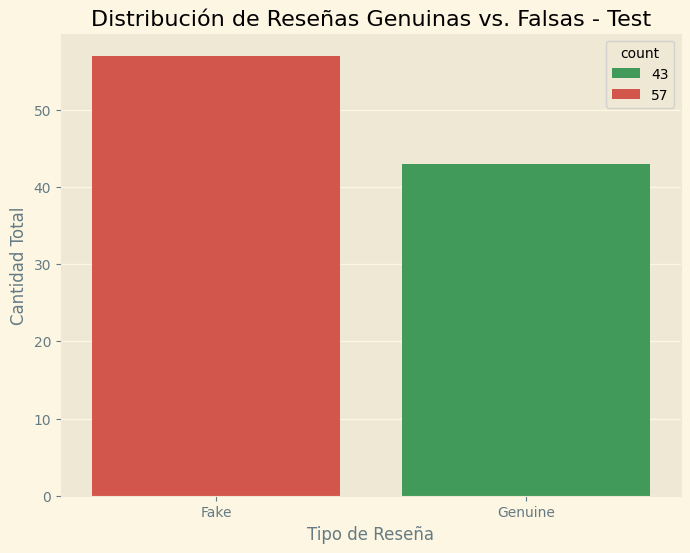

In [45]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_100['Cluster'].value_counts().to_pandas()
df_counts['Cluster'] = df_counts['Cluster'].replace({0: 'Fake', 1: 'Genuine'})
# Crear el gráfico de barras con Seaborn y Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Cluster', y='count', data=df_counts, palette=['#34A853', '#EA4335'], hue='count') # Genuine (verde), Fake (rojo)

# Añadir títulos y etiquetas
plt.title('Distribución de Reseñas Genuinas vs. Falsas - Test', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

## Visualización de la selección de los 1850 registros para Train/Validation

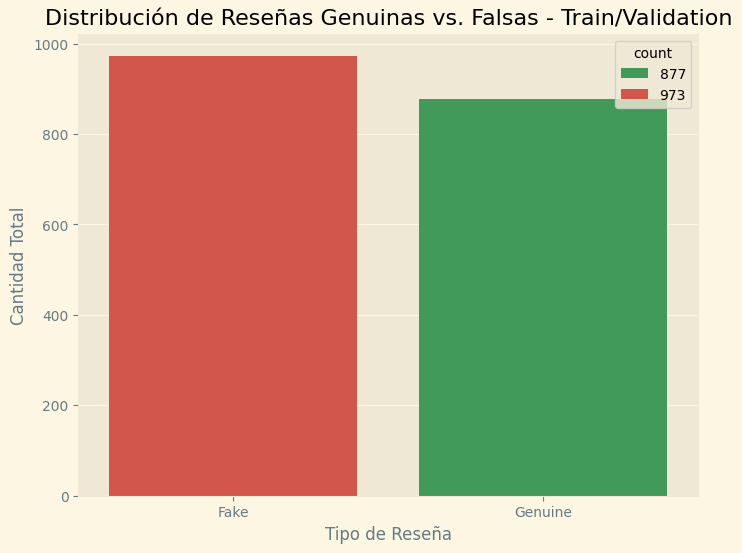

In [46]:
# Contar las ocurrencias de cada valor único en la columna 'classification'
df_counts = df_restante['Cluster'].value_counts().to_pandas()
df_counts['Cluster'] = df_counts['Cluster'].replace({0: 'Fake', 1: 'Genuine'})
# Crear el gráfico de barras con Seaborn y Matplotlib
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Cluster', y='count', data=df_counts, palette=['#34A853', '#EA4335'], hue='count') # Genuine (verde), Fake (rojo)

# Añadir títulos y etiquetas
plt.title('Distribución de Reseñas Genuinas vs. Falsas - Train/Validation', fontsize=16)
plt.xlabel('Tipo de Reseña', fontsize=12)
plt.ylabel('Cantidad Total', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

# Conclusión

Los conjuntos de datos destinados al entrenamiento y prueba de los modelos de IA han sido preparados y segmentados. El conjunto de entrenamiento/validación se compone de 877 reseñas "Genuinas" y 973 "Falsas". Por su parte, el conjunto de prueba presenta 43 reseñas "Genuinas" y 57 "Falsas". Esta distribución de las clases en ambos conjuntos establece el contexto con el que los modelos aprenderán a diferenciar los tipos de reseñas y sobre el cual se medirá su rendimiento final en la tarea de clasificación.



# Total ejecución del notebook

In [47]:
print(f'Total ejecución {time.time() - start_time_global:.2f} segundos')

Total ejecución 5.23 segundos
